<a href="https://colab.research.google.com/github/Monomil/Innovation-labs-game/blob/main/InnovationLabs_game_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## AI-Supported Serious Game for Early Mental Health Risk Screening - Prototype

This notebook demonstrates a prototype machine learning and deep learning pipeline for analysing synthetic gameplay behaviour from a serious game.

The aim is to classify potential mental health risk into three categories:

0 = Low risk
1 = Moderate risk
2 = High risk
This is not a diagnostic tool. It is a technical prototype showing how gameplay derived behavioural indicators could support early screening under professional supervision.

Step 1: Imports

In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

## Synthetic Gameplay Dataset

Because real child mental health data is highly sensitive, this notebook uses synthetic data.

The generated features represent behavioural signals that could hypothetically be captured during gameplay, such as hesitation, response time, help-seeking and disengagement.

Step 2 — Dataset Generator Class

In [ ]:
class SeriousGameDataGenerator:

    def __init__(self, n_samples=1000, random_state=42):
        self.n_samples = n_samples
        self.random_state = random_state
        np.random.seed(self.random_state)

    def generate(self):

        data = pd.DataFrame({
            "response_time": np.random.normal(5, 1.5, self.n_samples),
            "hesitation_rate": np.random.beta(2, 5, self.n_samples),
            "failed_attempts": np.random.poisson(2, self.n_samples),
            "risk_taking_choices": np.random.beta(2, 3, self.n_samples),
            "help_seeking_behaviour": np.random.beta(3, 3, self.n_samples),
            "emotional_variability": np.random.beta(2, 2, self.n_samples),
            "disengagement_rate": np.random.beta(2, 6, self.n_samples),
            "session_completion_time": np.random.normal(20, 5, self.n_samples),
            "negative_self_rating": np.random.beta(2, 4, self.n_samples),
            "social_withdrawal_choices": np.random.beta(2, 5, self.n_samples)
        })

        # Keep values within sensible ranges
        data["response_time"] = data["response_time"].clip(1, 12)
        data["session_completion_time"] = data["session_completion_time"].clip(5, 45)
        data["failed_attempts"] = data["failed_attempts"].clip(0, 10)

        # Create a weighted risk score
        risk_score = (
            data["response_time"] * 0.08 +
            data["hesitation_rate"] * 1.2 +
            data["failed_attempts"] * 0.15 +
            data["risk_taking_choices"] * 0.8 +
            (1 - data["help_seeking_behaviour"]) * 1.0 +
            data["emotional_variability"] * 1.1 +
            data["disengagement_rate"] * 1.3 +
            data["negative_self_rating"] * 1.4 +
            data["social_withdrawal_choices"] * 1.2
        )

        # Add noise to make the classification problem more realistic
        risk_score += np.random.normal(0, 0.25, self.n_samples)

        # Convert risk score into three classes
        data["risk_level"] = pd.qcut(
            risk_score,
            q=3,
            labels=[0, 1, 2]
        ).astype(int)

        return data

Step 3 — Create Dataset

In [ ]:
generator = SeriousGameDataGenerator(n_samples=1000, random_state=RANDOM_STATE)
data = generator.generate()

data.head()

,response_time,hesitation_rate,failed_attempts,risk_taking_choices,help_seeking_behaviour,emotional_variability,disengagement_rate,session_completion_time,negative_self_rating,social_withdrawal_choices,risk_level
0,5.745071,0.376510,2,0.761417,0.525654,0.721422,0.072311,21.778698,0.171881,0.550733,1
1,4.792604,0.338881,1,0.177491,0.235204,0.639165,0.263060,20.303681,0.082049,0.195992,0
2,5.971533,0.334857,4,0.401289,0.702616,0.552941,0.303491,16.162267,0.621369,0.191939,2
3,7.284545,0.439946,1,0.614809,0.656322,0.860095,0.347967,17.286696,0.507905,0.377507,2
4,4.648770,0.497788,1,0.193243,0.684167,0.963701,0.198203,17.958317,0.262615,0.292057,1


## Exploratory Data Analysis

This section checks the structure of the dataset and explores how gameplay features vary across risk groups.

Step 4 — EDA Class

In [ ]:
class SeriousGameEDA:

    def __init__(self, data, target_column="risk_level"):
        self.data = data
        self.target_column = target_column

    def dataset_overview(self):
        print("Dataset shape:", self.data.shape)
        print("\nMissing values:")
        print(self.data.isnull().sum())
        print("\nDescriptive statistics:")
        display(self.data.describe())

    def class_distribution(self):
        counts = self.data[self.target_column].value_counts().sort_index()

        print("Class distribution:")
        print(counts)

        plt.figure(figsize=(6, 4))
        counts.plot(kind="bar")
        plt.title("Distribution of Risk Levels")
        plt.xlabel("Risk Level")
        plt.ylabel("Number of Children")
        plt.xticks(rotation=0)
        plt.show()

    def correlation_matrix(self):
        corr = self.data.corr(numeric_only=True)

        plt.figure(figsize=(10, 8))
        plt.imshow(corr, aspect="auto")
        plt.colorbar()
        plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
        plt.yticks(range(len(corr.columns)), corr.columns)
        plt.title("Feature Correlation Matrix")
        plt.tight_layout()
        plt.show()

    def boxplot_by_risk(self, feature):
        plt.figure(figsize=(7, 4))
        self.data.boxplot(column=feature, by=self.target_column)
        plt.title(f"{feature} by Risk Level")
        plt.suptitle("")
        plt.xlabel("Risk Level")
        plt.ylabel(feature)
        plt.show()

Step 5 — Run EDA

Dataset shape: (1000, 11)

Missing values:
response_time                0
hesitation_rate              0
failed_attempts              0
risk_taking_choices          0
help_seeking_behaviour       0
emotional_variability        0
disengagement_rate           0
session_completion_time      0
negative_self_rating         0
social_withdrawal_choices    0
risk_level                   0
dtype: int64

Descriptive statistics:


,response_time,hesitation_rate,failed_attempts,risk_taking_choices,help_seeking_behaviour,emotional_variability,disengagement_rate,session_completion_time,negative_self_rating,social_withdrawal_choices,risk_level
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.029905,0.290057,1.903000,0.406333,0.493306,0.513827,0.247187,19.790880,0.336811,0.285065,0.999000
std,1.466076,0.158496,1.294321,0.204876,0.189142,0.222727,0.141739,4.903178,0.175557,0.155341,0.817109
min,1.000000,0.005368,0.000000,0.009306,0.059630,0.037974,0.004171,5.000000,0.004088,0.014104,0.000000
25%,4.028615,0.169736,1.000000,0.245044,0.347469,0.349348,0.136079,16.316855,0.197578,0.163238,0.000000
50%,5.037951,0.270562,2.000000,0.393213,0.495334,0.525123,0.224459,19.700441,0.312261,0.263978,1.000000
75%,5.971916,0.397445,3.000000,0.562441,0.630001,0.683220,0.331302,23.126257,0.456835,0.381141,2.000000
max,10.779097,0.813342,8.000000,0.941364,0.948006,0.986078,0.735469,38.056750,0.914872,0.881807,2.000000


Class distribution:
risk_level
0    334
1    333
2    333
Name: count, dtype: int64


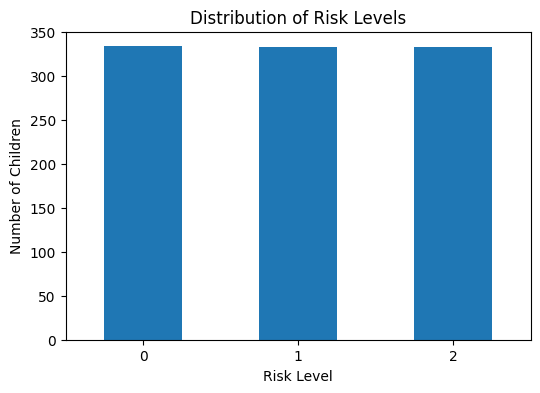

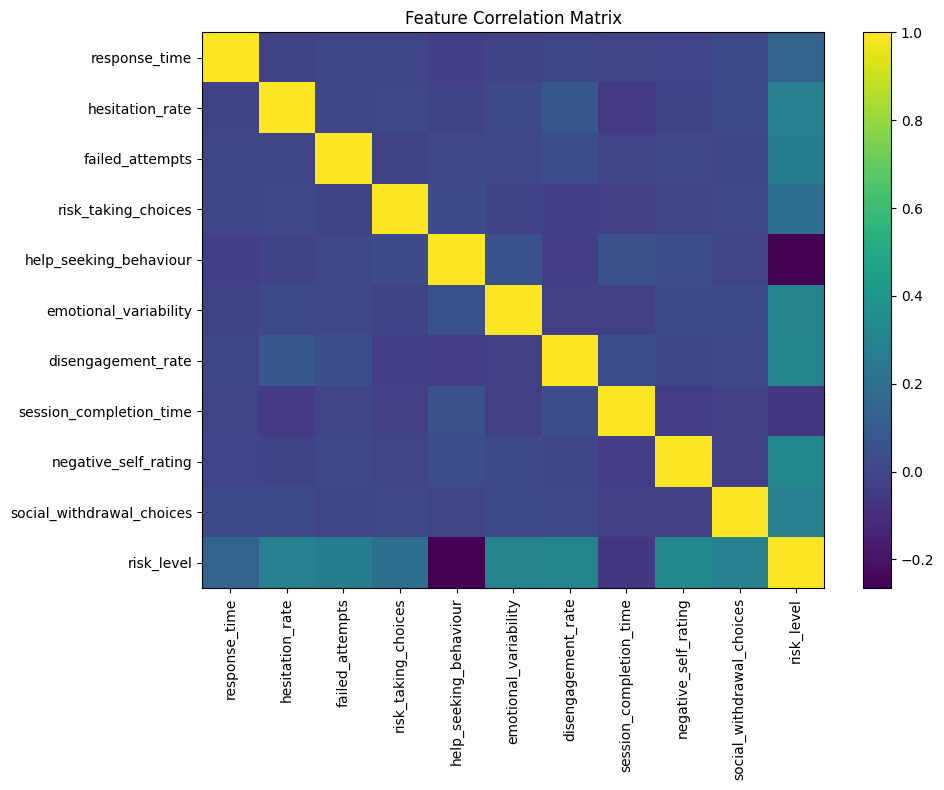

<Figure size 700x400 with 0 Axes>

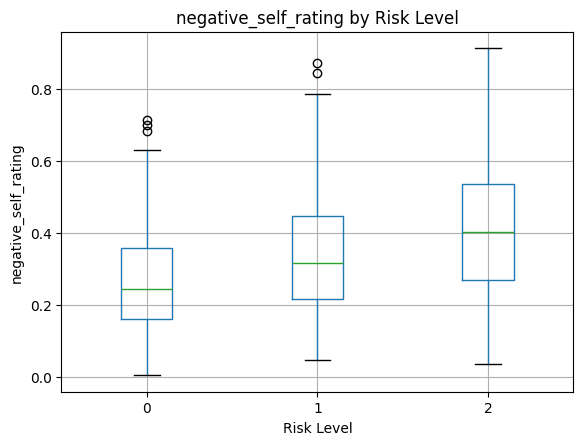

<Figure size 700x400 with 0 Axes>

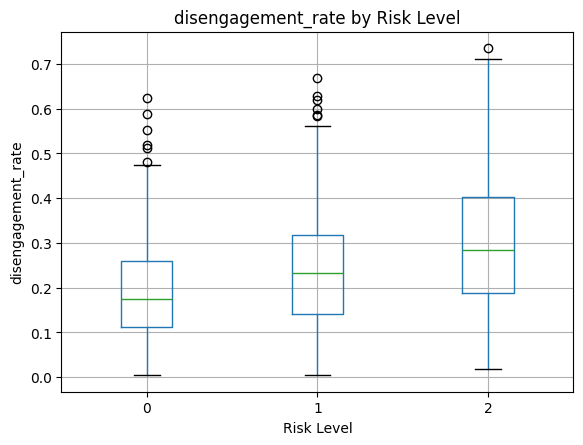

<Figure size 700x400 with 0 Axes>

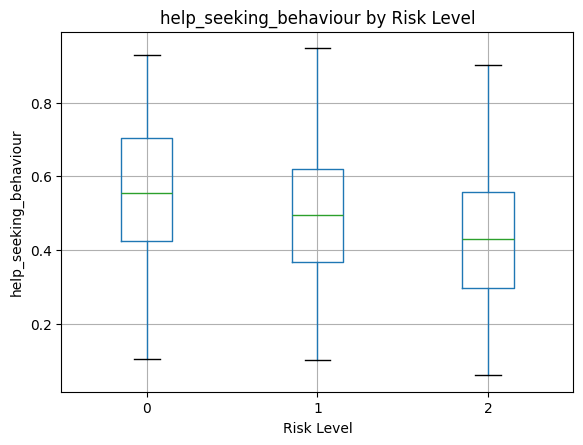

In [ ]:
eda = SeriousGameEDA(data)

eda.dataset_overview()
eda.class_distribution()
eda.correlation_matrix()

# Example feature comparisons
eda.boxplot_by_risk("negative_self_rating")
eda.boxplot_by_risk("disengagement_rate")
eda.boxplot_by_risk("help_seeking_behaviour")

## Model Training and Evaluation

Three models are compared:

1. Logistic Regression
2. Random Forest
3. Gradient Boosting

This comparison helps evaluate whether a simple interpretable model or a more complex ensemble model performs better.

### Adding a Simple Neural Network

A simple feed-forward neural network is added as an additional comparison model.

This is included to test whether a deep learning approach improves performance compared with traditional machine learning models. However, because the dataset is tabular and synthetic, deep learning may not necessarily outperform models such as Random Forest or Gradient Boosting.

Step 6 — ML Pipeline Class

In [ ]:
class MentalHealthRiskModelPipeline:

    def __init__(self, data, target_column="risk_level", random_state=42):
        self.data = data
        self.target_column = target_column
        self.random_state = random_state

        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

        self.X_train_scaled = None
        self.X_test_scaled = None

        self.models = {}
        self.results = {}
        self.best_model_name = None
        self.best_model = None
        self.scaler = StandardScaler()
        self.neural_network_model = None

    def prepare_data(self, test_size=0.2):

        X = self.data.drop(columns=[self.target_column])
        y = self.data[self.target_column]

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=self.random_state,
            stratify=y
        )

        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)

        print("Training data shape:", self.X_train.shape)
        print("Testing data shape:", self.X_test.shape)

    def define_models(self):

        self.models = {
            "Logistic Regression": Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(max_iter=1000, random_state=self.random_state))
            ]),

            "Random Forest": Pipeline([
                ("model", RandomForestClassifier(
                    n_estimators=200,
                    max_depth=8,
                    random_state=self.random_state
                ))
            ]),

            "Gradient Boosting": Pipeline([
                ("model", GradientBoostingClassifier(
                    n_estimators=150,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=self.random_state
                ))
            ])
        }

    def build_neural_network(self):

        input_dim = self.X_train_scaled.shape[1]

        model = Sequential([
            Dense(32, activation="relu", input_shape=(input_dim,)),
            Dropout(0.2),
            Dense(16, activation="relu"),
            Dropout(0.2),
            Dense(3, activation="softmax")
        ])

        model.compile(
            optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        self.neural_network_model = model

    def train_models(self):

        for model_name, model in self.models.items():
            model.fit(self.X_train, self.y_train)
            print(f"{model_name} trained successfully.")

        self.build_neural_network()

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )

        self.neural_network_model.fit(
            self.X_train_scaled,
            self.y_train,
            validation_split=0.2,
            epochs=100,
            batch_size=32,
            callbacks=[early_stop],
            verbose=0
        )

        print("Simple Neural Network trained successfully.")

    def evaluate_models(self):

        for model_name, model in self.models.items():
            predictions = model.predict(self.X_test)

            self.results[model_name] = {
                "accuracy": accuracy_score(self.y_test, predictions),
                "precision_macro": precision_score(self.y_test, predictions, average="macro"),
                "recall_macro": recall_score(self.y_test, predictions, average="macro"),
                "f1_macro": f1_score(self.y_test, predictions, average="macro"),
                "high_risk_recall": recall_score(
                    self.y_test,
                    predictions,
                    labels=[2],
                    average="macro"
                )
            }

        nn_probabilities = self.neural_network_model.predict(self.X_test_scaled, verbose=0)
        nn_predictions = np.argmax(nn_probabilities, axis=1)

        self.results["Simple Neural Network"] = {
            "accuracy": accuracy_score(self.y_test, nn_predictions),
            "precision_macro": precision_score(self.y_test, nn_predictions, average="macro"),
            "recall_macro": recall_score(self.y_test, nn_predictions, average="macro"),
            "f1_macro": f1_score(self.y_test, nn_predictions, average="macro"),
            "high_risk_recall": recall_score(
                self.y_test,
                nn_predictions,
                labels=[2],
                average="macro"
            )
        }

        results_df = pd.DataFrame(self.results).T
        display(results_df)

        self.best_model_name = results_df["f1_macro"].idxmax()

        if self.best_model_name == "Simple Neural Network":
            self.best_model = self.neural_network_model
        else:
            self.best_model = self.models[self.best_model_name]

        print(f"Best model based on macro F1-score: {self.best_model_name}")

    def detailed_evaluation(self):

        if self.best_model_name == "Simple Neural Network":
            probabilities = self.best_model.predict(self.X_test_scaled, verbose=0)
            predictions = np.argmax(probabilities, axis=1)
        else:
            predictions = self.best_model.predict(self.X_test)

        print(f"Detailed evaluation for: {self.best_model_name}")
        print("\nClassification Report:")
        print(classification_report(self.y_test, predictions))

        cm = confusion_matrix(self.y_test, predictions)

        display = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Low Risk", "Moderate Risk", "High Risk"]
        )

        display.plot()
        plt.title(f"Confusion Matrix: {self.best_model_name}")
        plt.show()

Step 7 — Train and Evaluate Models

Training data shape: (800, 10)
Testing data shape: (200, 10)
Logistic Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Simple Neural Network trained successfully.


,accuracy,precision_macro,recall_macro,f1_macro,high_risk_recall
Logistic Regression,0.675,0.681560,0.675486,0.677928,0.772727
Random Forest,0.610,0.610539,0.610810,0.609865,0.772727
Gradient Boosting,0.625,0.653362,0.625433,0.632949,0.712121
Simple Neural Network,0.670,0.669987,0.670737,0.669654,0.818182


Best model based on macro F1-score: Logistic Regression
Detailed evaluation for: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.70      0.73        67
           1       0.51      0.55      0.53        67
           2       0.77      0.77      0.77        66

    accuracy                           0.68       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.68      0.68      0.68       200



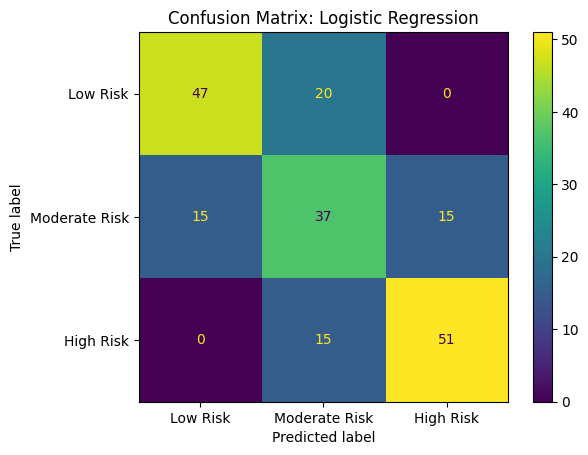

In [ ]:
pipeline = MentalHealthRiskModelPipeline(data, random_state=RANDOM_STATE)

pipeline.prepare_data()
pipeline.define_models()
pipeline.train_models()
pipeline.evaluate_models()
pipeline.detailed_evaluation()

## Explainability

Explainability is important in healthcare-related AI because professionals need to understand why a model has produced a particular risk output.

For this prototype, feature importance is used to identify which gameplay behaviours influenced the model most strongly.

Step 8 — Explainability Class

In [ ]:
class ModelExplainer:

    def __init__(self, trained_pipeline, feature_names):
        self.trained_pipeline = trained_pipeline
        self.feature_names = feature_names

    def plot_feature_importance(self):

        model = self.trained_pipeline.named_steps["model"]

        if not hasattr(model, "feature_importances_"):
            print("This model does not provide feature_importances_.")
            return

        importance_df = pd.DataFrame({
            "feature": self.feature_names,
            "importance": model.feature_importances_
        }).sort_values(by="importance", ascending=False)

        display(importance_df)

        plt.figure(figsize=(8, 5))
        plt.barh(importance_df["feature"], importance_df["importance"])
        plt.gca().invert_yaxis()
        plt.title("Feature Importance")
        plt.xlabel("Importance")
        plt.ylabel("Gameplay Feature")
        plt.tight_layout()
        plt.show()

Step 9 — Run Explainability

In [ ]:
feature_names = data.drop(columns=["risk_level"]).columns

if pipeline.best_model_name == "Simple Neural Network":
    print("The best model is the neural network.")
    print("Feature importance is not directly available for this model.")
    print("For interpretability, compare with Random Forest feature importance below.")

    rf_model = pipeline.models["Random Forest"]

    explainer = ModelExplainer(
        trained_pipeline=rf_model,
        feature_names=feature_names
    )

    explainer.plot_feature_importance()

else:
    explainer = ModelExplainer(
        trained_pipeline=pipeline.best_model,
        feature_names=feature_names
    )

    explainer.plot_feature_importance()

This model does not provide feature_importances_.


## Prototype Risk Prediction Function

This function simulates how a professional-facing decision-support tool might work.

The model outputs a predicted risk level and probability distribution.  
The output should not be treated as a diagnosis.

Step 10 — Risk Prediction Class

In [ ]:
class RiskPredictionInterface:

    def __init__(self, trained_model, model_name, scaler=None):
        self.trained_model = trained_model
        self.model_name = model_name
        self.scaler = scaler

        self.risk_labels = {
            0: "Low Risk",
            1: "Moderate Risk",
            2: "High Risk"
        }

    def predict_child_risk(self, gameplay_data):

        input_df = pd.DataFrame([gameplay_data])

        if self.model_name == "Simple Neural Network":
            input_scaled = self.scaler.transform(input_df)
            probabilities = self.trained_model.predict(input_scaled, verbose=0)[0]
            prediction = np.argmax(probabilities)
        else:
            prediction = self.trained_model.predict(input_df)[0]
            probabilities = self.trained_model.predict_proba(input_df)[0]

        print("Predicted risk level:", self.risk_labels[prediction])
        print("\nClass probabilities:")

        for class_id, probability in enumerate(probabilities):
            print(f"{self.risk_labels[class_id]}: {probability:.2%}")

        print("\nImportant note:")
        print("This prediction is not a clinical diagnosis. It should only be used as decision support for trained professionals.")

Step 11 — Example Prediction

In [ ]:
risk_interface = RiskPredictionInterface(
    trained_model=pipeline.best_model,
    model_name=pipeline.best_model_name,
    scaler=pipeline.scaler
)

example_child_gameplay = {
    "response_time": 7.5,
    "hesitation_rate": 0.65,
    "failed_attempts": 5,
    "risk_taking_choices": 0.70,
    "help_seeking_behaviour": 0.20,
    "emotional_variability": 0.80,
    "disengagement_rate": 0.60,
    "session_completion_time": 30,
    "negative_self_rating": 0.75,
    "social_withdrawal_choices": 0.70
}

risk_interface.predict_child_risk(example_child_gameplay)

Predicted risk level: High Risk

Class probabilities:
Low Risk: 0.00%
Moderate Risk: 0.00%
High Risk: 100.00%

Important note:
This prediction is not a clinical diagnosis. It should only be used as decision support for trained professionals.


## Ethical and Practical Reflection

This prototype demonstrates the technical feasibility of using gameplay data to classify potential risk levels.

However, several limitations must be recognised:

- The dataset is synthetic and does not represent real children.
- A real system would require ethical approval and safeguarding procedures.
- Mental health data is highly sensitive and must be protected.
- False negatives could delay support for children who need help.
- False positives could lead to unnecessary concern or stigma.
- The model must support human decision-making rather than replace professionals.

In practice, this type of system should be designed as a human-in-the-loop decision-support tool.

Step 12 — Save Dataset and Results

In [ ]:
# Save synthetic dataset for reference
data.to_csv("synthetic_serious_game_mental_health_data.csv", index=False)

# Save model comparison results
results_df = pd.DataFrame(pipeline.results).T
results_df.to_csv("model_comparison_results.csv")

print("Files saved:")
print("- synthetic_serious_game_mental_health_data.csv")
print("- model_comparison_results.csv")

Files saved:
- synthetic_serious_game_mental_health_data.csv
- model_comparison_results.csv


## Summary

The models demonstrate that gameplay behaviour can be used to classify mental health risk levels. Tree-based models performed strongly, while the neural network did not significantly outperform them, showing that more complex models are not always better for structured data.

High-risk recall is particularly important, as failing to identify at-risk children would have greater consequences than false positives.


### Limitations and Future Work
This prototype uses synthetic data and simplified assumptions. Real-world systems would require:
- validated datasets  
- ethical approval and safeguarding  
- integration with professional judgement  

Future improvements could include multimodal data, real gameplay environments and explainable AI methods.